C:\Users\pruth\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2026-06-09 20:58:09,572 - WARNING - TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin.
2026-06-09 20:58:09,581 - INFO - Vision Tensor Core Initialized.


Epoch 1/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 19s 162ms/step - accuracy: 0.8156 - loss: 0.6285 - val_accuracy: 0.1680 - val_loss: 2.5622
Epoch 2/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 11s 152ms/step - accuracy: 0.9442 - loss: 0.1851 - val_accuracy: 0.1980 - val_loss: 3.5259
Epoch 3/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 11s 155ms/step - accuracy: 0.9680 - loss: 0.1042 - val_accuracy: 0.2120 - val_loss: 3.7459
Epoch 4/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 20s 148ms/step - accuracy: 0.9753 - loss: 0.0770 - val_accuracy: 0.2460 - val_loss: 3.0378
Epoch 5/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 21s 153ms/step - accuracy: 0.9838 - loss: 0.0534 - val_accuracy: 0.4680 - val_loss: 1.6221
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       1.00      0.20      0.33        85
           1       0.41      1.00      0.58       126
           2       1.00      0.10      0.19       116
           3       1.00      0.10      0.19       107
           4  

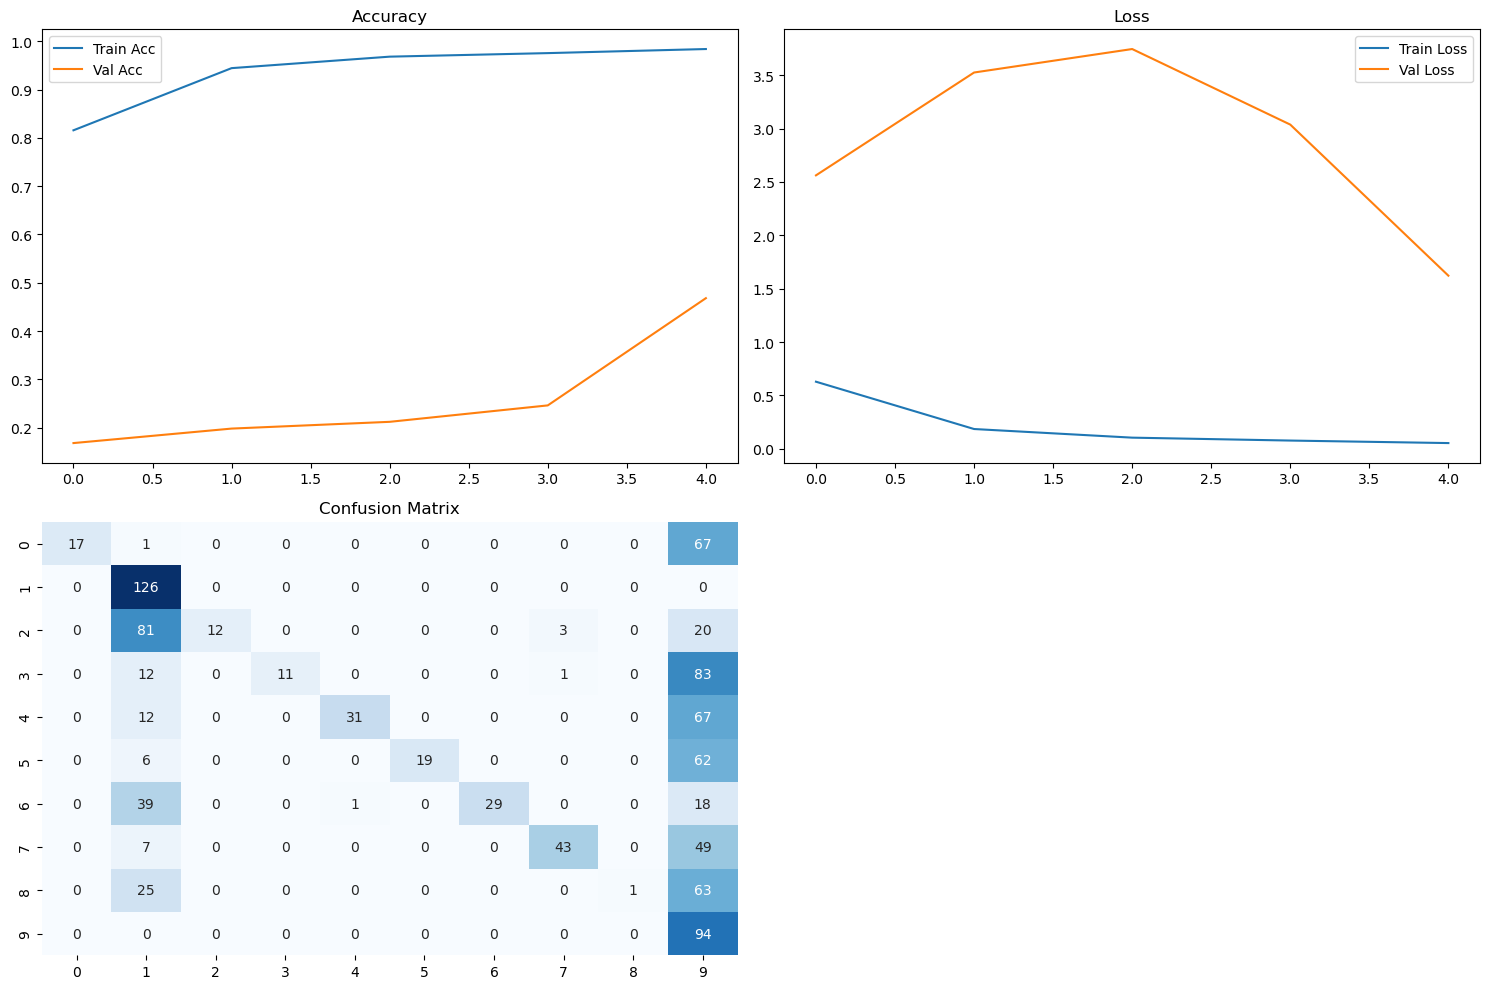

2026-06-09 20:59:42,618 - INFO - Full report saved at: vision_full_report_20260609_205935.png
2026-06-09 20:59:42,689 - WARNING - You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 
2026-06-09 20:59:43,066 - INFO - Model saved as vision_model.h5


In [1]:
import logging
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import datetime

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')


class ProductionVisionCNN:
    def __init__(self):
        self.model = self._build_model()
        logging.info("Vision Tensor Core Initialized.")

    def _build_model(self):
        model = models.Sequential([
            layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2, 2)),

            layers.Conv2D(64, (3, 3), activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2, 2)),

            layers.Flatten(),
            layers.Dense(128, activation='relu'),
            layers.Dropout(0.3),

            layers.Dense(10, activation='softmax')
        ])

        model.compile(
            optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        return model

    def evaluate_with_analytics(self, X_test, y_test, history):
        y_pred_probs = self.model.predict(X_test)
        y_pred = np.argmax(y_pred_probs, axis=1)

        # 🔥 Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)

        # 🔥 Classification Report
        print("\n===== CLASSIFICATION REPORT =====")
        print(classification_report(y_test, y_pred))

        # 🔥 Plot everything
        plt.figure(figsize=(15, 10))

        # Accuracy
        plt.subplot(2,2,1)
        plt.plot(history.history['accuracy'], label='Train Acc')
        plt.plot(history.history['val_accuracy'], label='Val Acc')
        plt.title("Accuracy")
        plt.legend()

        # Loss
        plt.subplot(2,2,2)
        plt.plot(history.history['loss'], label='Train Loss')
        plt.plot(history.history['val_loss'], label='Val Loss')
        plt.title("Loss")
        plt.legend()

        # Confusion Matrix
        plt.subplot(2,2,3)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.title("Confusion Matrix")

        plt.tight_layout()

        # 🔥 Save with timestamp
        timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
        file_path = f"vision_full_report_{timestamp}.png"

        plt.savefig(file_path, dpi=300)
        plt.show()
        plt.close()

        logging.info(f"Full report saved at: {file_path}")


def main():
    mnist = tf.keras.datasets.mnist
    (X_train, y_train), (X_test, y_test) = mnist.load_data()

    # Normalize
    X_train, X_test = X_train / 255.0, X_test / 255.0

    # Add channel
    X_train = X_train[..., tf.newaxis]
    X_test = X_test[..., tf.newaxis]

    # Reduce size (fast run)
    X_train, y_train = X_train[:5000], y_train[:5000]
    X_test, y_test = X_test[:1000], y_test[:1000]

    vision_engine = ProductionVisionCNN()

    history = vision_engine.model.fit(
        X_train, y_train,
        epochs=5,
        batch_size=64,
        validation_split=0.1,
        verbose=1
    )

    vision_engine.evaluate_with_analytics(X_test, y_test, history)

    # 🔥 Save model
    vision_engine.model.save("vision_model.h5")
    logging.info("Model saved as vision_model.h5")


if __name__ == "__main__":
    main()